[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/quantitative-research-methods/blob/main/Lab_Notebooks/chapter_12_lab.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Chapter 12 — Unsupervised Learning
## Lab: PCA, K-means, hierarchical clustering

**Course:** Quantitative Research Methods  
**Instructor:** Prof. Dr. Christoph Weisser, HSBI  
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com).


**Goal.** Run PCA on USArrests; cluster NCI60 with K-means and hierarchical methods.


## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.


> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and (once the repo is on GitHub and `GITHUB_RAW` is set) downloads the data automatically.



In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/quantitative-research-methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The three datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")

## 1. PCA on USArrests


In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
USA = load('USArrests')
Xs = StandardScaler().fit_transform(USA)
pca = PCA().fit(Xs)
print('PVE:', np.round(pca.explained_variance_ratio_, 3))
loadings = pd.DataFrame(pca.components_.T,
                         index=USA.columns,
                         columns=[f'PC{i+1}' for i in range(USA.shape[1])])
loadings.round(2)


PVE: [0.62  0.247 0.089 0.043]


,PC1,PC2,PC3,PC4
Murder,0.54,-0.42,-0.34,-0.65
Assault,0.58,-0.19,-0.27,0.74
UrbanPop,0.28,0.87,-0.38,-0.13
Rape,0.54,0.17,0.82,-0.09


### Biplot


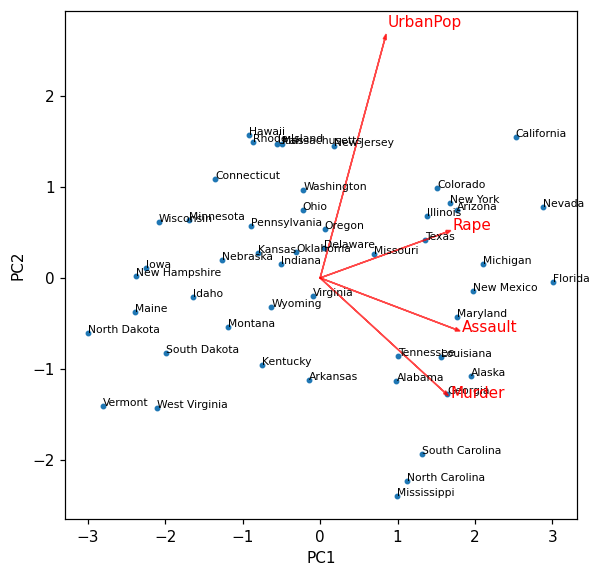

In [3]:
Z = pca.transform(Xs)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(Z[:, 0], Z[:, 1], s=8)
for i, name in enumerate(USA.index):
    ax.annotate(name, (Z[i, 0], Z[i, 1]), fontsize=7)
for j, var in enumerate(USA.columns):
    ax.arrow(0, 0, 3*pca.components_[0, j], 3*pca.components_[1, j],
             color='red', alpha=0.7, head_width=0.04)
    ax.text(3*pca.components_[0, j]*1.05, 3*pca.components_[1, j]*1.05,
             var, color='red')
ax.set(xlabel='PC1', ylabel='PC2'); plt.show()


### Scree plot


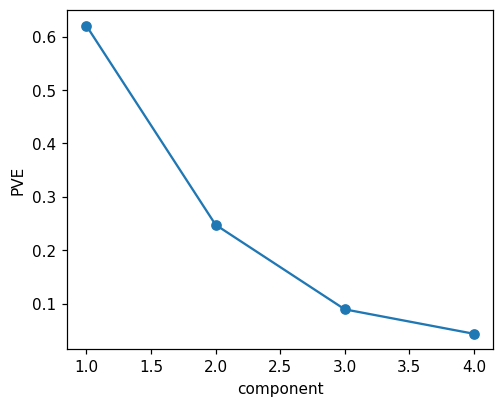

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(np.arange(1, 5), pca.explained_variance_ratio_, marker='o')
ax.set(xlabel='component', ylabel='PVE'); plt.show()


## 2. K-means


In [5]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, n_init=20, random_state=0).fit(Xs)
USA.assign(cluster=km.labels_).groupby('cluster').mean().round(2)


,Murder,Assault,UrbanPop,Rape
cluster,,,,
0,12.16,255.25,68.40,29.16
1,5.66,138.88,73.88,18.78
2,3.97,86.50,51.93,12.70


## 3. Hierarchical clustering


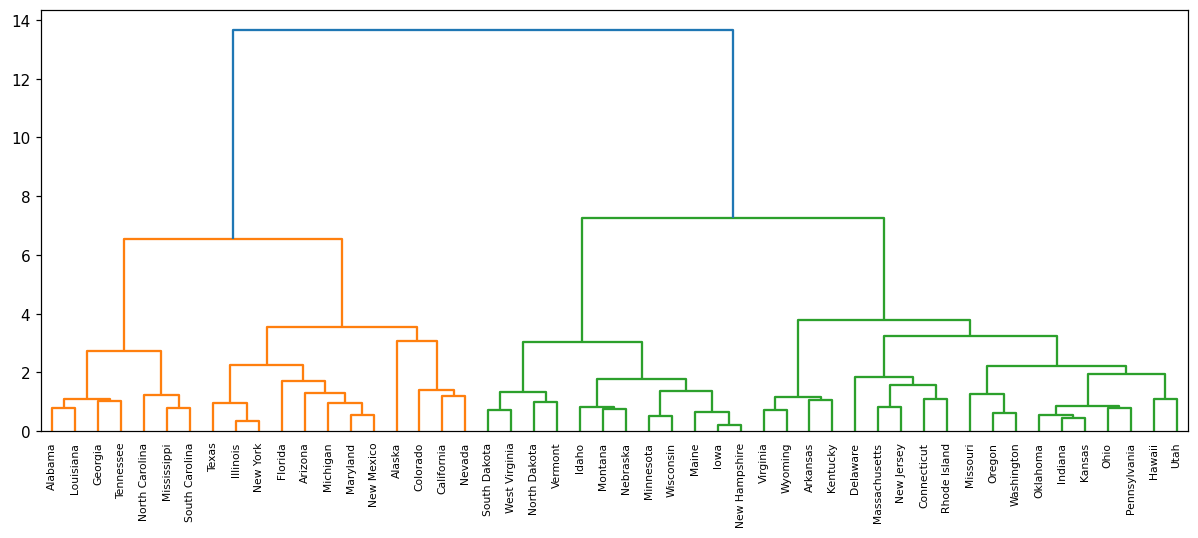

In [6]:
from scipy.cluster.hierarchy import linkage, dendrogram
Z = linkage(Xs, method='ward')
fig, ax = plt.subplots(figsize=(11, 5))
dendrogram(Z, labels=USA.index.tolist(), leaf_font_size=7, ax=ax)
plt.tight_layout(); plt.show()


## 4. Cluster the NCI60 data (optional)


In [7]:
if HAVE_ISLP:
    nci = load_data('NCI60')
    X = nci['data']; labs = nci['labels'].squeeze()
    Xs = StandardScaler().fit_transform(X)
    km = KMeans(n_clusters=4, n_init=20, random_state=0).fit(Xs)
    print(pd.crosstab(labs, km.labels_))
else:
    print('NCI60 ships only with the ISLP package.')


col_0        0  1  2  3
label                  
BREAST       0  3  2  2
CNS          0  5  0  0
COLON        0  0  7  0
K562A-repro  1  0  0  0
K562B-repro  1  0  0  0
LEUKEMIA     6  0  0  0
MCF7A-repro  0  0  1  0
MCF7D-repro  0  0  1  0
MELANOMA     0  1  0  7
NSCLC        1  4  4  0
OVARIAN      0  3  3  0
PROSTATE     0  1  1  0
RENAL        0  9  0  0
UNKNOWN      0  1  0  0


## 5. Exercises
1. Use the silhouette score to pick $K$ on USArrests.
2. Apply complete linkage and compare with Ward.
3. Plot the proportion-of-variance explained for the first 10 PCs of NCI60.
4. Implement the matrix-completion algorithm (iterative PCA imputation) on a data set with random missing entries.
